# Clase 2 — Guía de preprocesamiento y transformación de datos

**Bases de Datos Masivas (11088) — 2026**

Preprocesamiento:

| # | Tema | Dataset |
| --- | --- | --- |
| 1 | Manejo de ruido: binning por igual ancho y por igual frecuencia | sensores del invernadero |
| 2 | Discretización con Scikit-Learn (`KBinsDiscretizer`) | sensores del invernadero |
| 3 | QQ-Plot | sensores del invernadero |
| 4 | Histograma | sensores del invernadero |
| 5 | Boxplot | sensores del invernadero |
| 6 | Z-score | sensores del invernadero |
| 7 | Datos faltantes: visualización de los patrones | vinos (`load_wine`) |
| 8 | Imputación simple (media y moda) | vinos |
| 9 | Imputación con modelos implícitos (cold deck / hot deck) | vinos |
| 10 | Imputación por regresión (simple y MICE) | vinos |
| 11 | Reducción de dimensionalidad (PCA) | vinos |

### Los dos datasets

1. **Sensores del invernadero** (sintético, generado con semilla fija). Un
   registro cada 15 minutos durante 24 horas, con temperatura y CO₂. Es una serie **ordenada en el tiempo y con ruido conocido**: eso permite
   comparar el resultado de cada suavizado contra la señal "verdadera".
2. **Vinos** (`sklearn.datasets.load_wine`): 178 vinos del Piamonte, 13 mediciones
   químicas y la cepa de origen.

## 0. Librerías y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy import stats

SEMILLA = 2026
rng = np.random.default_rng(SEMILLA)

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


### El dataset de sensores

Simulamos dos sensores de un invernadero midiendo cada 15 minutos durante un día:

- `temp`: temperatura en °C. Sigue un ciclo diario (mínimo al amanecer, máximo a la tarde)
  más ruido de medición.
- `co2`: concentración de CO₂ en ppm. Va **en contrafase** con la temperatura: de día las
  plantas consumen CO₂, de noche lo liberan.

Además inyectamos tres lecturas erróneas.

In [2]:
n = 96  # 96 registros de 15 minutos = 24 horas
ts = pd.date_range("2026-03-15 00:00", periods=n, freq="15min")
hora = ts.hour + ts.minute / 60

temp_real = 22 + 5 * np.sin(2 * np.pi * (hora - 8) / 24)
co2_real = 800 - 250 * np.sin(2 * np.pi * (hora - 8) / 24)

sensor = pd.DataFrame({
    "ts": ts,
    "hora": hora,
    "temp": temp_real + rng.normal(0, 0.9, n),   # + ruido de medición
    "co2": co2_real + rng.normal(0, 45, n),
    "temp_real": temp_real,                       # para comparar
})

# lecturas erróneas
sensor.loc[37, "temp"] = 41.2
sensor.loc[70, "temp"] = 6.4
sensor.loc[12, "co2"] = 2180.0

sensor.head()

,ts,hora,temp,co2,temp_real
0,2026-03-15 00:00:00,0.00,16.956,999.300,17.670
1,2026-03-15 00:15:00,0.25,17.732,1035.497,17.516
2,2026-03-15 00:30:00,0.50,15.674,983.130,17.381
3,2026-03-15 00:45:00,0.75,18.522,989.625,17.265
4,2026-03-15 01:00:00,1.00,17.745,953.406,17.170


In [3]:
sensor[["temp", "co2"]].describe()

,temp,co2
count,96.000,96.000
mean,22.073,815.894
std,4.548,229.327
min,6.400,461.888
25%,18.287,642.652
50%,22.012,802.646
75%,25.464,981.039
max,41.200,2180.000


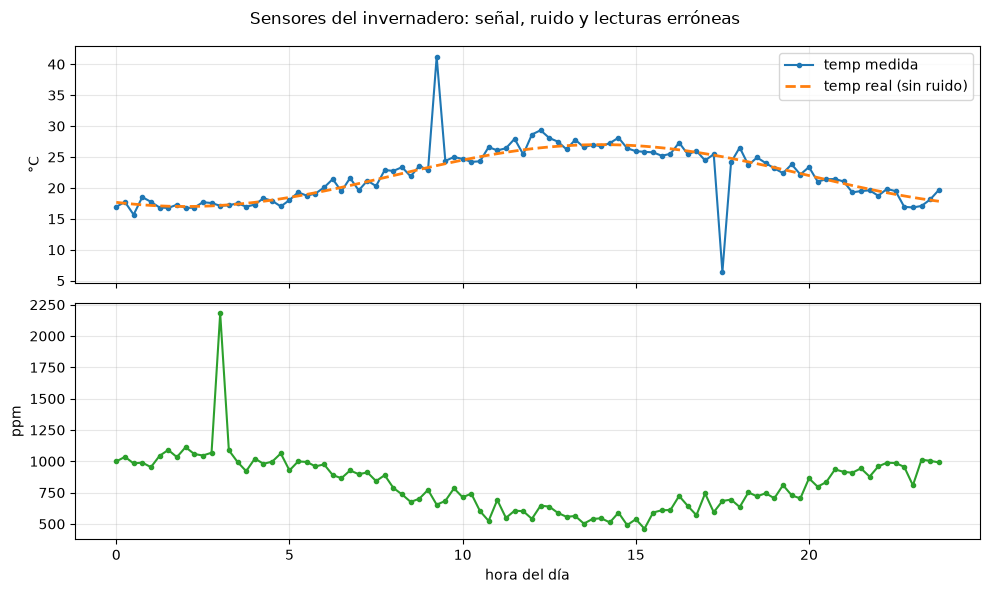

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(sensor.hora, sensor.temp, marker=".", label="temp medida")
ax[0].plot(sensor.hora, sensor.temp_real, lw=2, ls="--", label="temp real (sin ruido)")
ax[0].set_ylabel("°C"); ax[0].legend()
ax[1].plot(sensor.hora, sensor.co2, marker=".", color="tab:green")
ax[1].set_ylabel("ppm"); ax[1].set_xlabel("hora del día")
fig.suptitle("Sensores del invernadero: señal, ruido y lecturas erróneas")
plt.tight_layout()
plt.show()

Las 3 mediciones erróneas se ven a simple vista. El resto del desvío respecto de la línea punteada
es el **ruido** de medición: no son errores, es la imprecisión propia del instrumento.

## 1. Manejo de ruido: Binning

El *binning* agrupa los valores en **bins** y reemplaza cada valor por un
representante del bin al que cayó. Es un suavizado: se pierde detalle y se gana estabilidad.

Dos decisiones independientes:

| Decisión | Opciones |
| --- | --- |
| **Cómo se arman los bins** | igual ancho (mismo rango) · igual frecuencia (misma cantidad de casos) |
| **Con qué valor se reemplaza** | media · mediana |

### 1.1 Binning por igual ancho (*equal-width*)

`pd.cut` parte el **rango** `[min, max]` en `k` intervalos del mismo ancho. La cantidad
de observaciones por bin queda librada a cómo se distribuyan los datos, y un outlier estira
el rango entero.

In [5]:
K = 4  # cantidad de bins

sensor["bin_ancho"] = pd.cut(sensor.temp, bins=K)
sensor["bin_ancho"].value_counts().sort_index()

bin_ancho
(6.365, 15.1]     1
(15.1, 23.8]     57
(23.8, 32.5]     37
(32.5, 41.2]      1
Name: count, dtype: int64

In [6]:
# Suavizado por medias: cada valor se reemplaza por la media de su bin.
# transform() devuelve una serie alineada al índice original
sensor["temp_EW"] = sensor.groupby("bin_ancho", observed=True)["temp"].transform("mean")

sensor[["temp", "bin_ancho", "temp_EW"]].head(8)

,temp,bin_ancho,temp_EW
0,16.956,"(15.1, 23.8]",19.413
1,17.732,"(15.1, 23.8]",19.413
2,15.674,"(15.1, 23.8]",19.413
3,18.522,"(15.1, 23.8]",19.413
4,17.745,"(15.1, 23.8]",19.413
5,16.833,"(15.1, 23.8]",19.413
6,16.762,"(15.1, 23.8]",19.413
7,17.284,"(15.1, 23.8]",19.413


### 1.2 Binning por igual frecuencia (*equal-frequency*)

`pd.qcut` usa **cuantiles**: cada bin recibe (aproximadamente) la misma cantidad de
observaciones, así que los bins son anchos donde hay pocos datos y angostos donde se
amontonan. Es mucho más robusto a los outliers que el igual ancho.

In [7]:
sensor["bin_frec"] = pd.qcut(sensor.temp, q=K)
sensor["bin_frec"].value_counts().sort_index()

bin_frec
(6.399, 18.287]     24
(18.287, 22.012]    24
(22.012, 25.464]    24
(25.464, 41.2]      24
Name: count, dtype: int64

In [8]:
sensor["temp_EF"] = sensor.groupby("bin_frec", observed=True)["temp"].transform("mean")

sensor[["temp", "bin_frec", "temp_EF"]].head(8)

,temp,bin_frec,temp_EF
0,16.956,"(6.399, 18.287]",16.761
1,17.732,"(6.399, 18.287]",16.761
2,15.674,"(6.399, 18.287]",16.761
3,18.522,"(18.287, 22.012]",20.021
4,17.745,"(6.399, 18.287]",16.761
5,16.833,"(6.399, 18.287]",16.761
6,16.762,"(6.399, 18.287]",16.761
7,17.284,"(6.399, 18.287]",16.761


### 1.3 Comparación de los dos suavizados

Como generamos la señal nosotros, podemos hacer algo que con datos reales sería imposible:
medir **cuánto se acercó cada suavizado a la señal verdadera**. Usamos el error cuadrático
medio (RMSE) contra `temp_real`.

In [9]:
def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

comparacion = pd.DataFrame({
    "método": ["sin suavizar", "igual ancho + media", "igual frecuencia + media"],
    "RMSE vs señal real": [rmse(sensor.temp, sensor.temp_real),
                           rmse(sensor.temp_EW, sensor.temp_real),
                           rmse(sensor.temp_EF, sensor.temp_real)],
    "desvío estándar": [sensor.temp.std(), sensor.temp_EW.std(), sensor.temp_EF.std()],
})
comparacion

,método,RMSE vs señal real,desvío estándar
0,sin suavizar,2.770,4.548
1,igual ancho + media,3.148,4.114
2,igual frecuencia + media,1.546,4.078


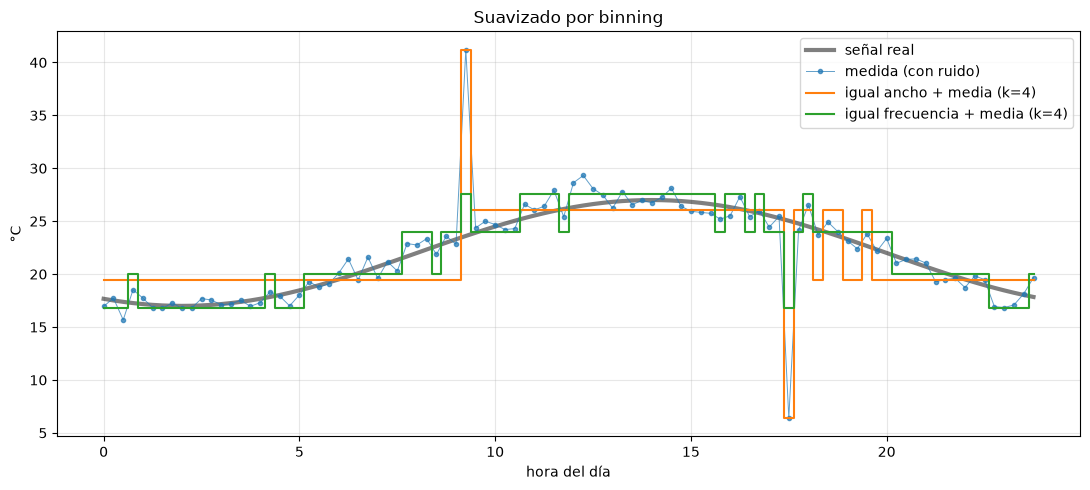

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sensor.hora, sensor.temp_real, lw=3, color="black", alpha=.5, label="señal real")
ax.plot(sensor.hora, sensor.temp, marker=".", lw=.7, alpha=.7, label="medida (con ruido)")
ax.step(sensor.hora, sensor.temp_EW, where="mid", label=f"igual ancho + media (k={K})")
ax.step(sensor.hora, sensor.temp_EF, where="mid", label=f"igual frecuencia + media (k={K})")
ax.set_xlabel("hora del día"); ax.set_ylabel("°C")
ax.set_title("Suavizado por binning")
ax.legend()
plt.tight_layout()
plt.show()

El resultado más interesante de la tabla es que el **igual ancho quedó peor que no suavizar**
(RMSE 3,15 contra 2,77), mientras que el igual frecuencia bajó el error casi a la mitad
(1,55).

| | bin 1 | bin 2 | bin 3 | bin 4 |
| --- | --- | --- | --- | --- |
| igual ancho | 1 | 57 | 37 | 1 |
| igual frecuencia | 24 | 24 | 24 | 24 |

Las dos lecturas erróneas se llevaron un bin cada una, así que 94 de las 96 observaciones
quedaron aplastadas en dos bins. **Un solo outlier arruina el binning por igual
ancho**, porque define el rango que después se divide en partes iguales. El igual frecuencia
lo absorbe sin problema: el outlier es un caso más dentro de su cuartil.

Y algo que vale para las dos variantes: **el binning no ordena por tiempo**, agrupa por
valor. Dos mediciones de las 3 de la mañana y de las 11 de la noche caen en el mismo bin si
tienen temperatura parecida.

### 1.4 ¿Cuántos bins conviene usar?

Hasta acá fijamos `k = 4` sin justificarlo. Probemos **todos** los valores posibles de `k`
—desde 2 hasta 96, que es la cantidad de observaciones que tenemos— y midamos en cada caso
el error contra la señal real.

Cómo se lee el gráfico que sigue:

- El eje vertical es el **error**: más abajo es mejor. El eje horizontal es `k`, en escala
  logarítmica para que los valores chicos no queden apretados contra el borde.
- La línea roja punteada es el error de la serie **sin suavizar** (2,77 °C). Todo lo que
  quede por debajo es una mejora; todo lo que quede por encima significa que el suavizado
  empeoró las cosas.
- **Zona naranja (k chico).** Pocos bins, muy anchos. Con `k = 2` la serie entera se
  convierte en dos escalones: se fue el ruido, pero también la forma del ciclo diario. El
  error es alto no por el ruido que quedó, sino porque la escalera **no se parece** a la
  curva verdadera. Eso es el **sesgo**.
- **Zona violeta (k grande).** Muchos bins, con pocas observaciones cada uno. Promediar dos
  o tres valores casi no cancela el ruido, así que el suavizado se le parece cada vez más a
  los datos crudos. Eso es la **varianza**. En el extremo, `k = 96` da un bin por
  observación: la media de un solo valor es ese valor, no suaviza nada, y por eso la curva
  **toca la línea roja**.
- El **mínimo** (k = 4) es el punto donde los dos efectos se equilibran. Ése es el
  compromiso sesgo–varianza, y aparece en cualquier técnica que tenga un parámetro de
  suavizado.

Los escalones del tramo derecho no son un artefacto: la cantidad de observaciones por bin es
un número entero, así que el error cambia de golpe cada vez que se pasa de promediar cuatro
datos a tres, de tres a dos, y de dos a uno.

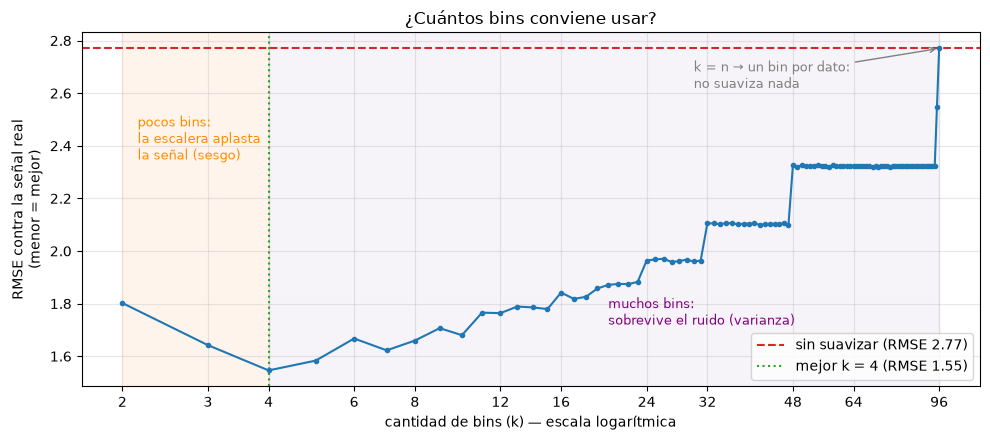

In [11]:
curva = []
for k in range(2, len(sensor) + 1):
    b = pd.qcut(sensor.temp, q=k, duplicates="drop")
    suave = sensor.groupby(b, observed=True)["temp"].transform("mean")
    curva.append({"k": k, "obs por bin": len(sensor) / k,
                  "RMSE": rmse(suave, sensor.temp_real)})
curva = pd.DataFrame(curva)

base = rmse(sensor.temp, sensor.temp_real)
mejor = curva.loc[curva.RMSE.idxmin()]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(curva.k, curva.RMSE, marker=".", color="tab:blue", zorder=3)
ax.axhline(base, ls="--", color="tab:red", label=f"sin suavizar (RMSE {base:.2f})")
ax.axvline(mejor.k, ls=":", color="tab:green",
           label=f"mejor k = {int(mejor.k)} (RMSE {mejor.RMSE:.2f})")
ax.axvspan(2, mejor.k, alpha=.08, color="tab:orange")
ax.axvspan(mejor.k, curva.k.max(), alpha=.08, color="tab:purple")

ax.set_xscale("log", base=2)
ax.set_xticks([2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.text(2.15, 2.52, "pocos bins:\nla escalera aplasta\nla señal (sesgo)",
        fontsize=9, color="darkorange", va="top")
ax.text(20, 1.72, "muchos bins:\nsobrevive el ruido (varianza)", fontsize=9, color="purple")
ax.annotate("k = n \u2192 un bin por dato:\nno suaviza nada", xy=(96, base),
            xytext=(30, 2.62), fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("cantidad de bins (k) \u2014 escala logarítmica")
ax.set_ylabel("RMSE contra la señal real\n(menor = mejor)")
ax.set_title("¿Cuántos bins conviene usar?")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
# Los valores detrás del gráfico, para los k redondos
curva[curva.k.isin([2, 3, 4, 6, 8, 12, 24, 32, 48, 96])].round(2).set_index("k")

,obs por bin,RMSE
k,,
2,48.0,1.80
3,32.0,1.64
4,24.0,1.55
6,16.0,1.67
8,12.0,1.66
12,8.0,1.76
24,4.0,1.96
32,3.0,2.10
48,2.0,2.33


Y esto es lo mismo visto sobre la serie: los cuatro `k` que corresponden a los puntos
señalados en el gráfico anterior.

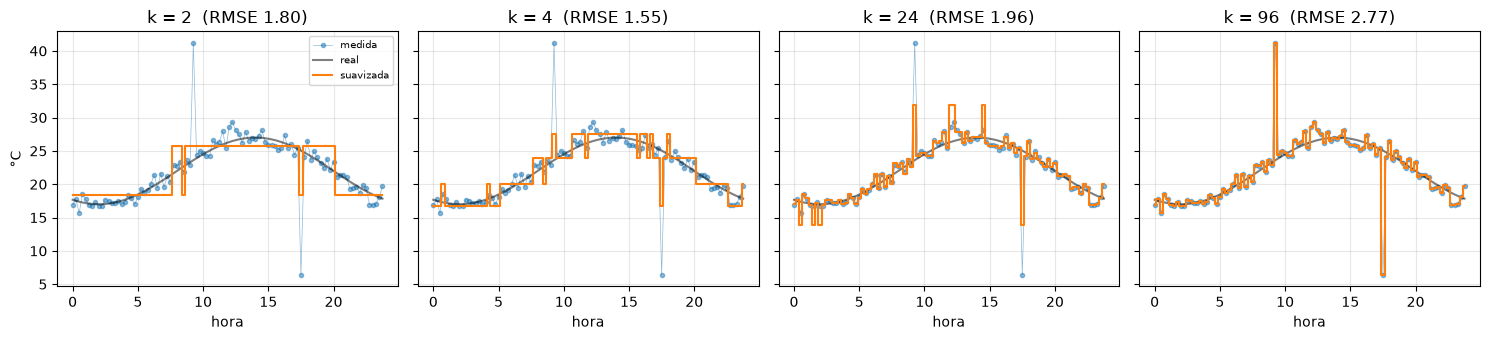

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for k, ax in zip([2, 4, 24, 96], axes):
    b = pd.qcut(sensor.temp, q=k, duplicates="drop")
    suave = sensor.groupby(b, observed=True)["temp"].transform("mean")
    ax.plot(sensor.hora, sensor.temp, marker=".", lw=.5, alpha=.5, label="medida")
    ax.plot(sensor.hora, sensor.temp_real, color="black", alpha=.5, label="real")
    ax.step(sensor.hora, suave, where="mid", color="tab:orange", label="suavizada")
    ax.set_title(f"k = {k}  (RMSE {rmse(suave, sensor.temp_real):.2f})")
    ax.set_xlabel("hora")
axes[0].set_ylabel("°C"); axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 2. Discretización con Scikit-Learn

`KBinsDiscretizer` hace lo mismo que `cut`/`qcut` pero como **transformador**: aprende los
cortes con `fit` sobre el conjunto de entrenamiento y los aplica igual a datos nuevos con
`transform`. Esa es la diferencia que importa en producción — con `pd.qcut` los cortes se
recalculan con cada dataset y dejan de ser comparables.

Estrategias:

| `strategy` | Cortes | Equivalente en pandas |
| --- | --- | --- |
| `uniform` | ancho igual | `pd.cut` |
| `quantile` | frecuencia igual | `pd.qcut` |
| `kmeans` | centroides de k-means 1D | — |

In [14]:
from sklearn.preprocessing import KBinsDiscretizer

X = sensor[["temp"]]

for estrategia in ["uniform", "quantile", "kmeans"]:
    disc = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy=estrategia,
                            random_state=SEMILLA)
    codigos = disc.fit_transform(X).ravel().astype(int)
    print(f"{estrategia:9s} cortes: {np.round(disc.bin_edges_[0], 2)}")
    print(f"{'':9s} casos por bin: {np.bincount(codigos)}\n")

uniform   cortes: [ 6.4 15.1 23.8 32.5 41.2]
          casos por bin: [ 1 57 37  1]

quantile  cortes: [ 6.4  18.24 22.01 25.48 41.2 ]
          casos por bin: [24 24 24 24]

kmeans    cortes: [ 6.4  12.52 22.04 33.31 41.2 ]
          casos por bin: [ 1 47 47  1]



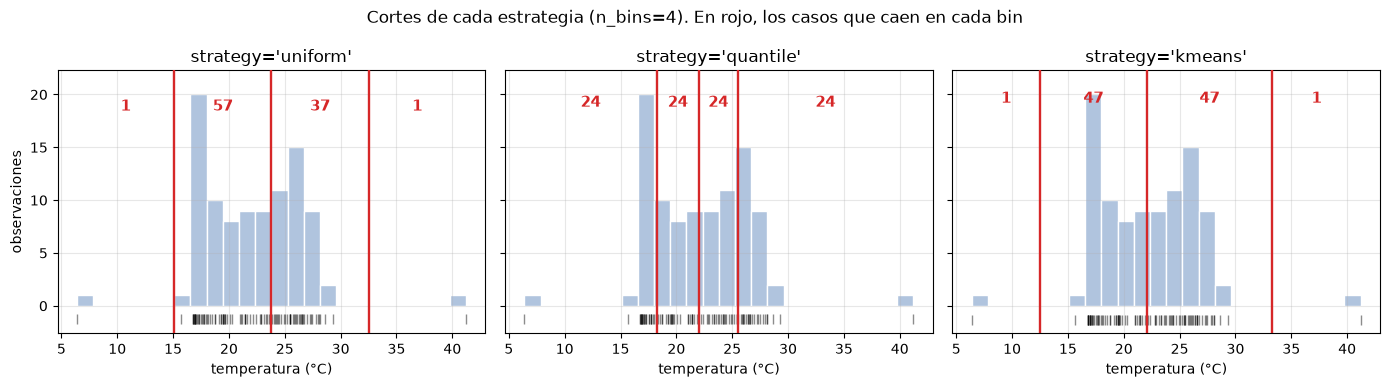

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9), sharey=True)

for estrategia, ax in zip(["uniform", "quantile", "kmeans"], axes):
    disc = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy=estrategia,
                            random_state=SEMILLA)
    codigos = disc.fit_transform(X).ravel().astype(int)
    cortes = disc.bin_edges_[0]

    ax.hist(sensor.temp, bins=24, color="lightsteelblue", edgecolor="white")
    top = ax.get_ylim()[1]

    for c in cortes[1:-1]:                      # los cortes internos, en rojo
        ax.axvline(c, color="tab:red", lw=1.7, zorder=3)

    for i, cuenta in enumerate(np.bincount(codigos, minlength=4)):
        ax.text((cortes[i] + cortes[i + 1]) / 2, top * .88, str(cuenta),
                ha="center", fontsize=11, color="tab:red", fontweight="bold")

    ax.plot(sensor.temp, np.full(len(sensor), -top * .06), "|",
            color="black", alpha=.45, ms=7)

    ax.set_ylim(-top * .12, top * 1.02)
    ax.set_title(f"strategy=\'{estrategia}\'")
    ax.set_xlabel("temperatura (°C)")

axes[0].set_ylabel("observaciones")
fig.suptitle("Cortes de cada estrategia (n_bins=4). En rojo, los casos que caen en cada bin")
plt.tight_layout()
plt.show()

Los tres paneles tienen los mismos datos y la misma cantidad de bins; lo único que cambia es
dónde caen los cortes rojos.

- **`uniform`** reparte el **rango** en cuatro tramos iguales de 8,7 °C. Como las dos lecturas
  erróneas estiran el rango de 6,4 a 41,2 °C, los bins de los extremos se quedan con una sola
  observación cada uno y las 94 restantes se apiñan en los dos del medio. Es exactamente el
  problema de la sección 1.1, ahora visto sobre el histograma.
- **`quantile`** reparte los **casos**: los tres cortes se amontonan entre 18 y 25,5 °C, que
  es donde está la masa de los datos, y cada bin recibe 24 observaciones. Los outliers pasan
  a ser un caso más dentro del primer y del último bin.
- **`kmeans`** busca grupos naturales sobre el eje de la variable, y acá termina igual de mal
  que `uniform` (1 / 47 / 47 / 1): con sólo cuatro centroides disponibles, dos se van a
  "cazar" las lecturas erróneas. Que la estrategia sea más sofisticada no la hace robusta.

In [16]:
# encode='ordinal' devuelve el número de bin; 'onehot-dense', las variables indicadoras
disc = KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile")
dummies = disc.fit_transform(X)
pd.DataFrame(dummies, columns=disc.get_feature_names_out()).head()

,temp_0.0,temp_1.0,temp_2.0,temp_3.0
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0


In [17]:
disc = KBinsDiscretizer(n_bins=6, encode="ordinal", strategy="quantile")
codigos = disc.fit_transform(X)
sensor["temp_KBD"] = disc.inverse_transform(codigos)

sensor[["temp", "temp_KBD"]].head()

,temp,temp_KBD
0,16.956,11.908
1,17.732,18.441
2,15.674,11.908
3,18.522,18.441
4,17.745,18.441


## 3. QQ-Plot

El *quantile-quantile plot* compara los cuantiles observados contra los de una distribución
teórica (por defecto, la normal). Si los puntos siguen la diagonal, la variable se
distribuye como esa teórica.

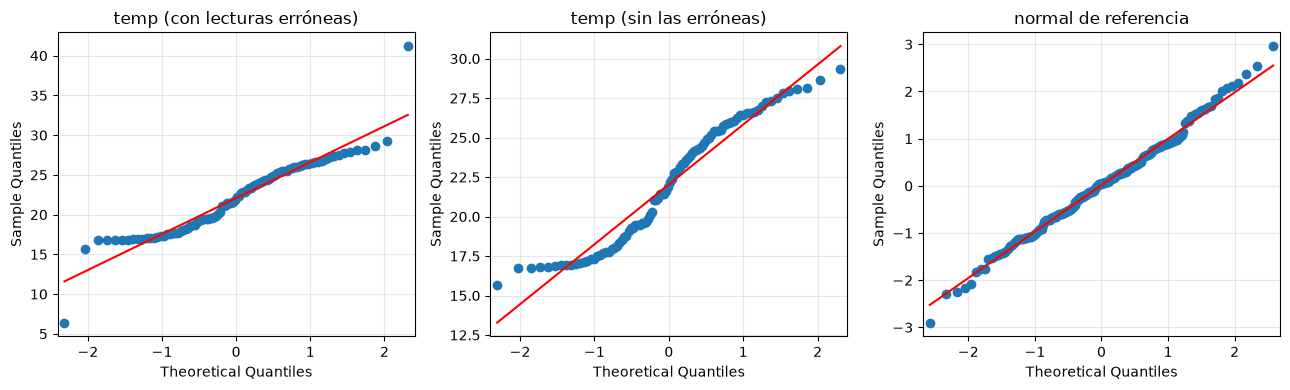

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sm.qqplot(sensor.temp.to_numpy(), line="s", ax=axes[0])
axes[0].set_title("temp (con lecturas erróneas)")

limpia = sensor.temp.drop(index=[37, 70]).to_numpy()
sm.qqplot(limpia, line="s", ax=axes[1])
axes[1].set_title("temp (sin las erróneas)")

sm.qqplot(rng.normal(size=200), line="s", ax=axes[2])
axes[2].set_title("normal de referencia")

plt.tight_layout()
plt.show()

En el primer panel los dos puntos de los extremos se despegan de la recta: son las lecturas
erróneas. Sacándolas, el gráfico del medio muestra una curva en forma de S suave — no es
ruido, es que la temperatura tiene distribución **bimodal** (día y noche), no normal.

In [19]:
# Contraste formal
for nombre, x in [("temp completa", sensor.temp.to_numpy()),
                  ("temp sin erróneas", limpia),
                  ("co2", sensor.co2.to_numpy())]:
    est, p = stats.shapiro(x)
    print(f"{nombre:20s} Shapiro-Wilk W={est:.3f}  p={p:.2e}  "
          f"{'no rechaza normalidad' if p > 0.05 else 'rechaza normalidad'}")

temp completa        Shapiro-Wilk W=0.927  p=4.90e-05  rechaza normalidad
temp sin erróneas    Shapiro-Wilk W=0.933  p=1.30e-04  rechaza normalidad
co2                  Shapiro-Wilk W=0.829  p=3.59e-09  rechaza normalidad


## 4. Histograma

La cantidad de bins del histograma no es un detalle estético: cambia la conclusión. Con
pocos bins se pierde la bimodalidad; con demasiados, cada barra es una observación.
`bins="auto"` aplica la regla de Freedman-Diaconis o la de Sturges, la que dé más bins.

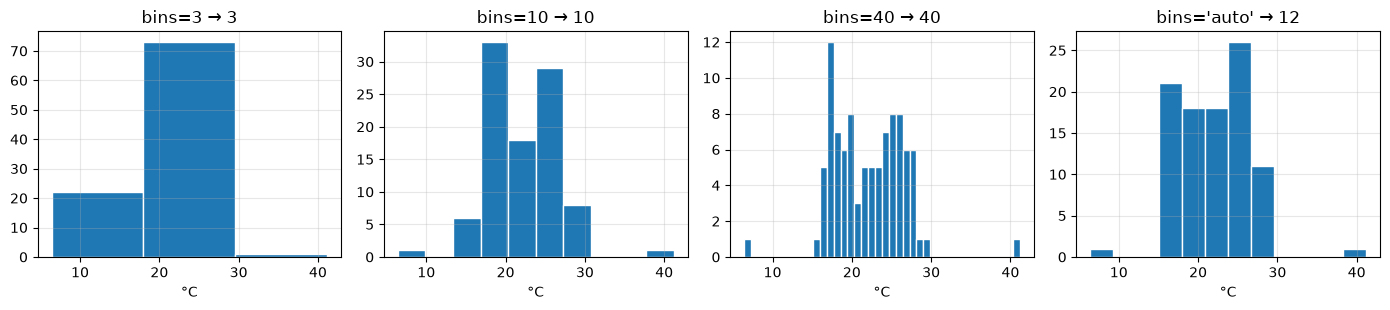

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=False)
for b, ax in zip([3, 10, 40, "auto"], axes):
    ax.hist(sensor.temp, bins=b, edgecolor="white")
    n_bins = len(np.histogram_bin_edges(sensor.temp, bins=b)) - 1
    ax.set_title(f"bins={b!r} → {n_bins}")
    ax.set_xlabel("°C")
plt.tight_layout()
plt.show()

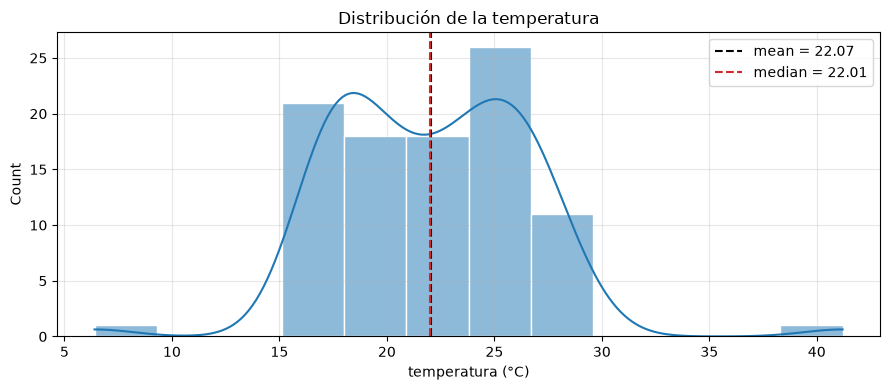

In [21]:
# Histograma + densidad estimada (KDE) + medidas de tendencia central
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(sensor.temp, bins="auto", kde=True, ax=ax, edgecolor="white")
for medida, color in [("mean", "black"), ("median", "tab:red")]:
    valor = getattr(sensor.temp, medida)()
    ax.axvline(valor, color=color, ls="--", label=f"{medida} = {valor:.2f}")
ax.set_xlabel("temperatura (°C)"); ax.legend()
ax.set_title("Distribución de la temperatura")
plt.tight_layout()
plt.show()

## 5. Boxplot

El boxplot resume la distribución con cinco números —mínimo, primer cuartil, mediana, tercer
cuartil y máximo—, dibuja la caja entre Q1 y Q3, y deja fuera de los bigotes, como puntos
sueltos, las observaciones que quedan lejos del cuerpo de los datos.

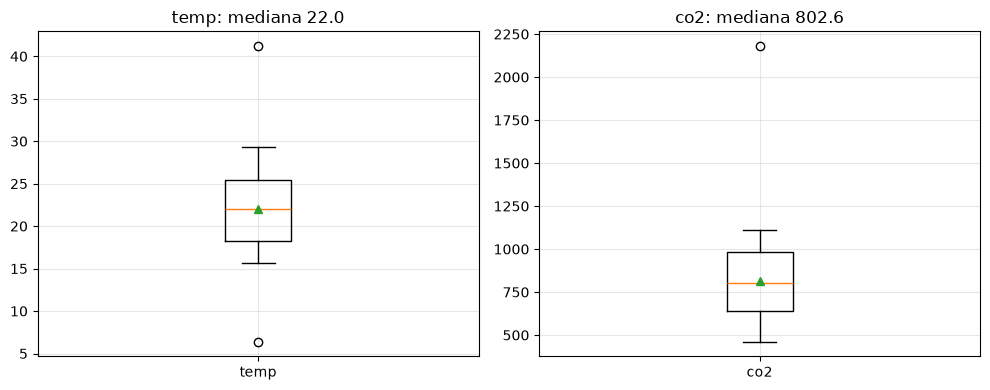

,temp,co2
0.00,6.400,461.888
0.25,18.287,642.652
0.50,22.012,802.646
0.75,25.464,981.039
1.00,41.200,2180.000


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for col, ax in zip(["temp", "co2"], axes):
    ax.boxplot(sensor[col].dropna(), tick_labels=[col], showmeans=True)
    ax.set_title(f"{col}: mediana {sensor[col].median():.1f}")
plt.tight_layout()
plt.show()

sensor[["temp", "co2"]].quantile([0, .25, .5, .75, 1])

### 5.1 ¿Qué mueve un outlier y qué no?

Comparamos la temperatura con y sin las dos lecturas erróneas. Lo interesante del gráfico que
sigue es lo que **no** cambia.

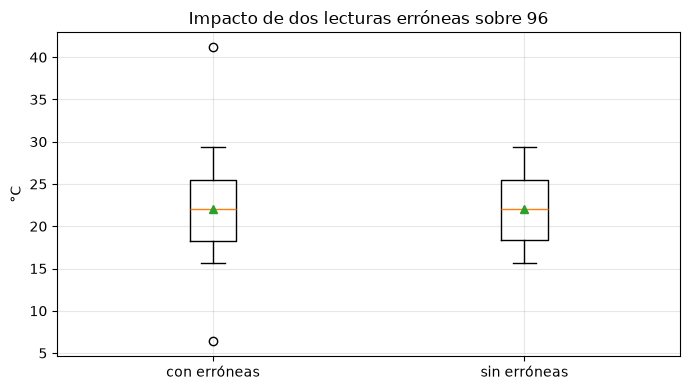

In [23]:
sin_err = sensor.temp.drop(index=[37, 70])

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([sensor.temp, sin_err], tick_labels=["con erróneas", "sin erróneas"],
           showmeans=True)
ax.set_ylabel("°C")
ax.set_title("Impacto de dos lecturas erróneas sobre 96")
plt.tight_layout()
plt.show()

In [24]:
def resumen_robustez(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    return pd.Series({
        "media": serie.mean(),
        "desvío": serie.std(),
        "rango (máx - mín)": serie.max() - serie.min(),
        "Q1": q1,
        "mediana": serie.median(),
        "Q3": q3,
        "IQR": q3 - q1,
    })

robustez = pd.DataFrame({
    "con erróneas": resumen_robustez(sensor.temp),
    "sin erróneas": resumen_robustez(sin_err),
})
robustez["% de cambio"] = 100 * (robustez["con erróneas"] / robustez["sin erróneas"] - 1)
robustez.round(2)

,con erróneas,sin erróneas,% de cambio
media,22.07,22.04,0.17
desvío,4.55,3.81,19.22
rango (máx - mín),34.80,13.65,155.01
Q1,18.29,18.38,-0.52
mediana,22.01,22.01,0.00
Q3,25.46,25.45,0.07
IQR,7.18,7.06,1.62


### 5.2 Boxplot por grupos

Comparar la misma variable entre grupos es el uso más productivo del boxplot: revela si un
valor es raro **en términos absolutos** o sólo **dentro de su grupo**.

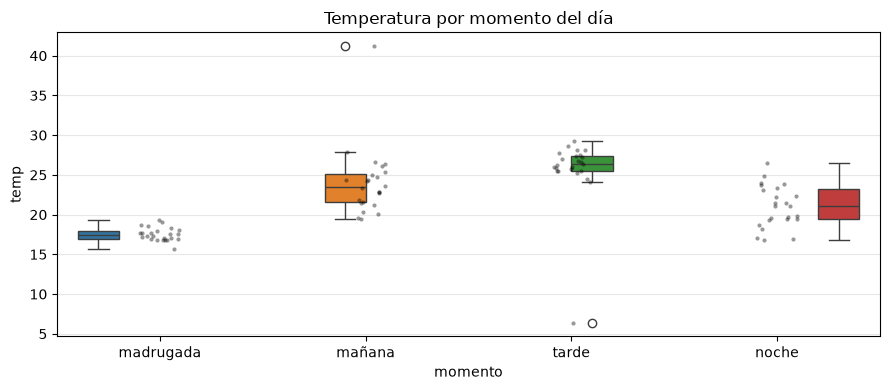

,count,mean,std,min,max
momento,,,,,
madrugada,24,17.535,0.838,15.674,19.294
mañana,24,24.046,4.327,19.445,41.200
tarde,24,25.708,4.309,6.400,29.320
noche,24,21.003,2.630,16.840,26.529


In [25]:
sensor["momento"] = pd.cut(sensor.hora, bins=[0, 6, 12, 18, 24],
                           labels=["madrugada", "mañana", "tarde", "noche"],
                           right=False)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=sensor, x="momento", y="temp", ax=ax, hue="momento", legend=False)
sns.stripplot(data=sensor, x="momento", y="temp", ax=ax, color="black", alpha=.4, size=3)
ax.set_title("Temperatura por momento del día")
plt.tight_layout()
plt.show()

sensor.groupby("momento", observed=True)["temp"].agg(["count", "mean", "std", "min", "max"])

## 6. Z-score

El z-score centra y escala la variable: le resta la media y la divide por el desvío estándar,
dejándola con media 0 y desvío 1.

$$z = \frac{v - \mu}{\sigma}$$

El valor transformado se lee directamente como "a cuántos desvíos de la media está esta
observación", y eso lo hace útil para dos cosas distintas: **comparar** variables medidas en
unidades diferentes, y **describir** qué tan atípica es una observación.

In [26]:
sensor["temp_z"] = stats.zscore(sensor.temp)
sensor["co2_z"] = stats.zscore(sensor.co2)

sensor[["temp", "temp_z", "co2", "co2_z"]].head()

,temp,temp_z,co2,co2_z
0,16.956,-1.131,999.300,0.804
1,17.732,-0.959,1035.497,0.963
2,15.674,-1.414,983.130,0.733
3,18.522,-0.785,989.625,0.762
4,17.745,-0.957,953.406,0.603


In [27]:
# El equivalente de Scikit-Learn, reutilizable sobre datos nuevos
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler().fit(sensor[["temp", "co2"]])
print("medias :", escalador.mean_.round(2))
print("desvíos:", np.sqrt(escalador.var_).round(2))

sensor[["temp", "temp_z", "co2", "co2_z"]].describe().loc[["mean", "std", "min", "max"]]

medias : [ 22.07 815.89]
desvíos: [  4.52 228.13]


,temp,temp_z,co2,co2_z
mean,22.073,-1.078e-15,815.894,-1.897e-16
std,4.548,1.005e+00,229.327,1.005e+00
min,6.400,-3.464e+00,461.888,-1.552e+00
max,41.200,4.228e+00,2180.000,5.980e+00


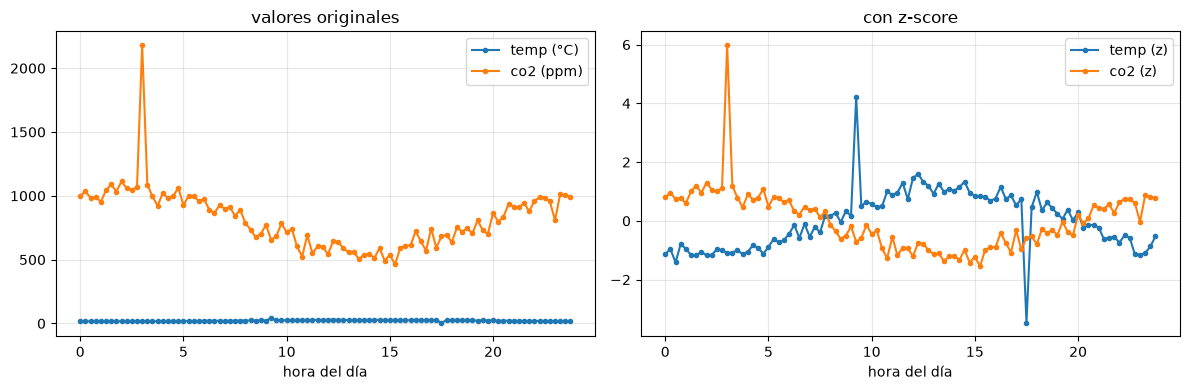

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sensor.hora, sensor.temp, marker=".", label="temp (°C)")
axes[0].plot(sensor.hora, sensor.co2, marker=".", label="co2 (ppm)")
axes[0].set_title("valores originales"); axes[0].legend()
axes[1].plot(sensor.hora, sensor.temp_z, marker=".", label="temp (z)")
axes[1].plot(sensor.hora, sensor.co2_z, marker=".", label="co2 (z)")
axes[1].set_title("con z-score"); axes[1].legend()
for ax in axes:
    ax.set_xlabel("hora del día")
plt.tight_layout()
plt.show()

En el panel izquierdo la temperatura es una línea plana pegada al piso: `co2` va de 500 a
2180 y `temp` de 6 a 41, así que en un mismo eje la primera desaparece. Con el z-score las
dos entran en la misma escala.

---

# Parte 2 — Datos faltantes y reducción de dimensionalidad

## 7. Datos faltantes

Pasamos al dataset de **vinos**: 178 muestras del Piamonte con 13 mediciones químicas y la
cepa (`clase`). Viene completo, así que **borramos
valores nosotros** y guardamos el original como referencia, para después poder comparar cada
imputación contra el valor que realmente había.

In [29]:
from sklearn.datasets import load_wine

vinos_ori = load_wine(as_frame=True)
vinos_ori = vinos_ori.frame.assign(
    clase=pd.Categorical.from_codes(vinos_ori.target,
                                    ["barolo", "grignolino", "barbera"])
).drop(columns="target")

NUM = [c for c in vinos_ori.columns if c != "clase"]

print("dimensiones:", vinos_ori.shape, "| faltantes:", int(vinos_ori.isna().sum().sum()))
vinos_ori.head()

dimensiones: (178, 14) | faltantes: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,barolo
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,barolo
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,barolo
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,barolo
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,barolo


In [30]:
# Borramos al azar alrededor del 18 % de tres variables numéricas y el 8 % de la cepa
rng_na = np.random.default_rng(SEMILLA)
vinos = vinos_ori.copy()

FALTAN = ["flavanoids", "magnesium", "proline"]
for col in FALTAN:
    vinos.loc[rng_na.random(len(vinos)) < 0.18, col] = np.nan
vinos.loc[rng_na.random(len(vinos)) < 0.08, "clase"] = np.nan

MASCARA = vinos[FALTAN].isna()   # dónde borramos: nos sirve para comparar después

resumen_na = pd.DataFrame({
    "faltantes": vinos.isna().sum(),
    "% faltante": (100 * vinos.isna().mean()).round(1),
})
resumen_na[resumen_na.faltantes > 0]

,faltantes,% faltante
magnesium,30,16.9
flavanoids,25,14.0
proline,33,18.5
clase,10,5.6


### 7.1 Visualización de los faltantes con `missingno`

`describe()` y `isna().sum()` dan los números; `missingno` muestra el **patrón**, que es lo
que permite entender donde están los faltantes.

In [31]:
vinos.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
alcohol,178.0,NaN,NaN,NaN,13.001,0.812,11.03,12.362,13.05,13.678,14.83
malic_acid,178.0,NaN,NaN,NaN,2.336,1.117,0.74,1.603,1.865,3.083,5.8
ash,178.0,NaN,NaN,NaN,2.367,0.274,1.36,2.21,2.36,2.558,3.23
alcalinity_of_ash,178.0,NaN,NaN,NaN,19.495,3.34,10.6,17.2,19.5,21.5,30.0
magnesium,148.0,NaN,NaN,NaN,100.331,13.451,78.0,89.0,98.0,108.0,162.0
total_phenols,178.0,NaN,NaN,NaN,2.295,0.626,0.98,1.742,2.355,2.8,3.88
flavanoids,153.0,NaN,NaN,NaN,2.081,0.995,0.47,1.25,2.24,2.9,5.08
nonflavanoid_phenols,178.0,NaN,NaN,NaN,0.362,0.124,0.13,0.27,0.34,0.438,0.66
proanthocyanins,178.0,NaN,NaN,NaN,1.591,0.572,0.41,1.25,1.555,1.95,3.58
color_intensity,178.0,NaN,NaN,NaN,5.058,2.318,1.28,3.22,4.69,6.2,13.0


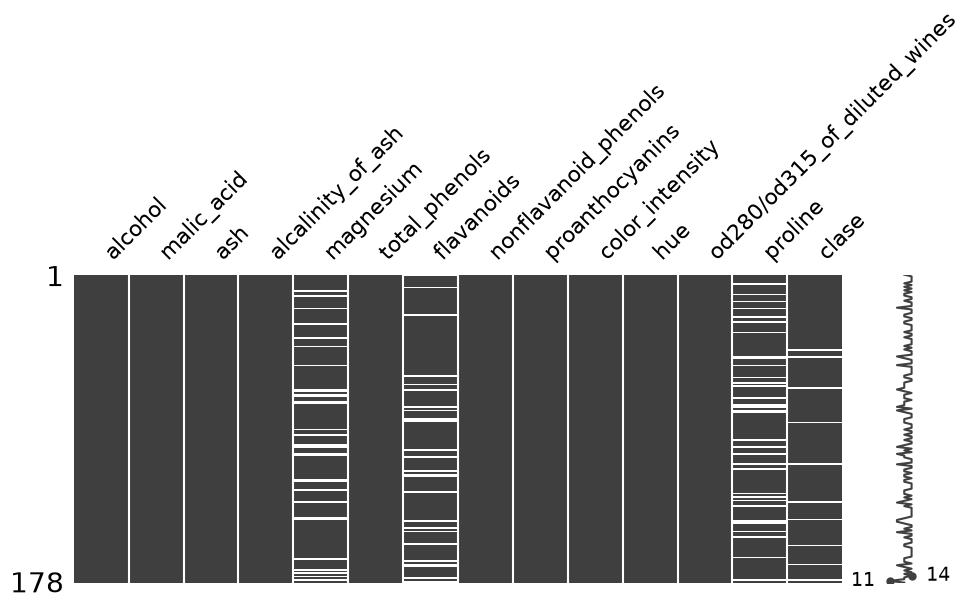

In [32]:
import missingno as msno

msno.matrix(vinos, figsize=(11, 4))
plt.show()

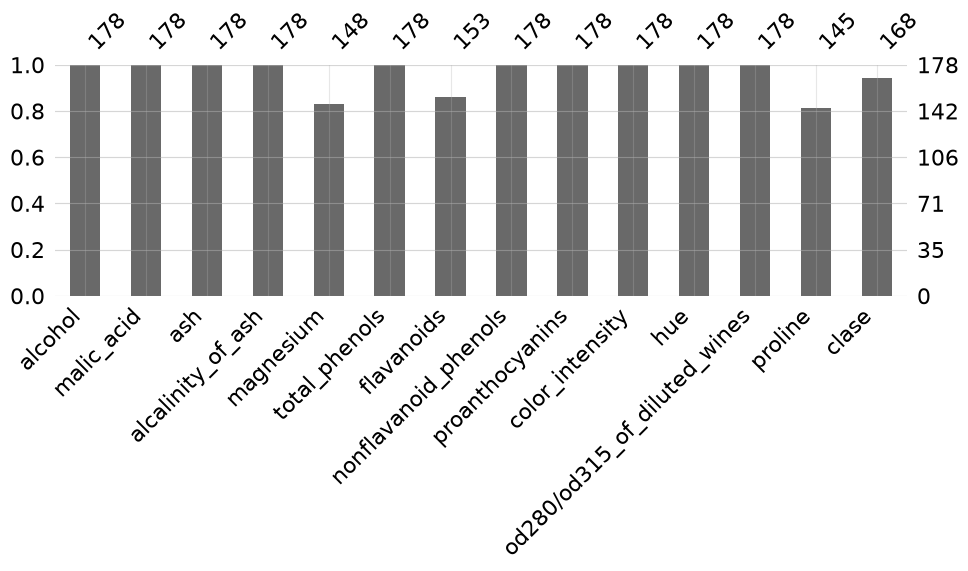

In [33]:
msno.bar(vinos, figsize=(11, 3))
plt.show()

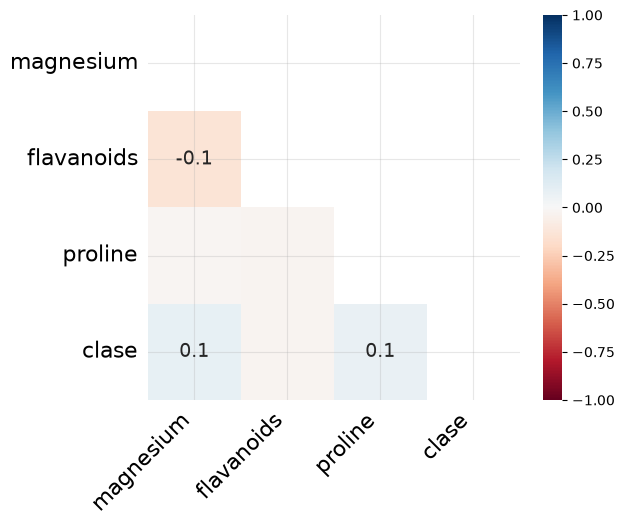

In [34]:
# Correlación de nulidad: ¿los faltantes de una variable acompañan a los de otra?
msno.heatmap(vinos, figsize=(6, 5))
plt.show()

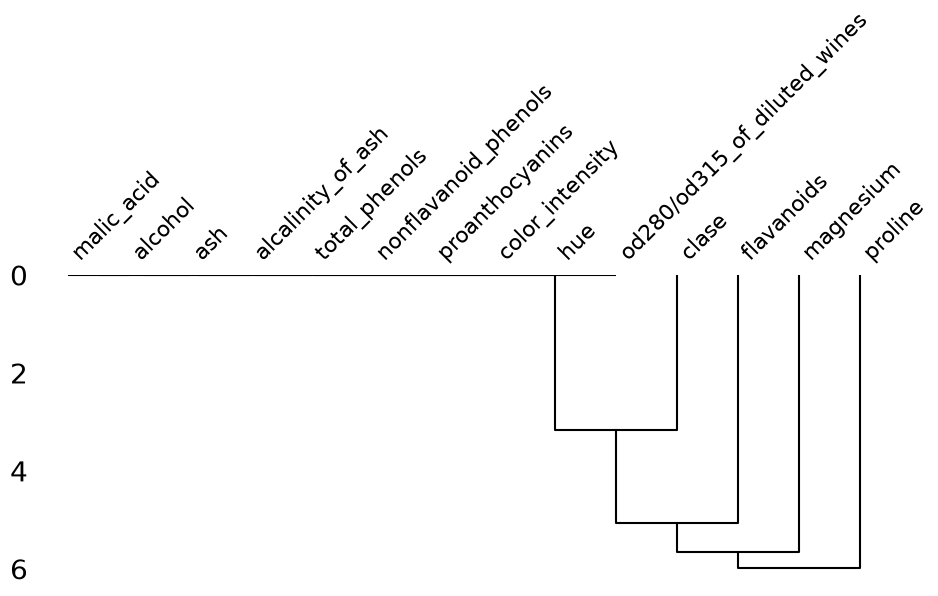

In [35]:
# El dendrograma agrupa variables por similitud de su patrón de faltantes
msno.dendrogram(vinos, figsize=(11, 4))
plt.show()

In [36]:
# El costo de dropna(): tres variables incompletas se llevan casi la mitad del dataset
print(f"filas originales      : {len(vinos)}")
print(f"filas completas       : {len(vinos.dropna())}")
print(f"se perdería           : {100 * (1 - len(vinos.dropna()) / len(vinos)):.1f} %")

filas originales      : 178
filas completas       : 96
se perdería           : 46.1 %


## 8. Imputación simple

La imputación puntual reemplaza cada faltante por una medida de tendencia central de la
variable: **media** (o mediana) para las numéricas, **moda** para las categóricas.

In [37]:
medias = vinos[NUM].mean()
medias[FALTAN]

flavanoids      2.081
magnesium     100.331
proline       750.552
dtype: float64

In [38]:
vinos_media = vinos.copy()
vinos_media[NUM] = vinos_media[NUM].fillna(medias)

vinos_media[FALTAN].describe().loc[["count", "mean", "std"]]

,flavanoids,magnesium,proline
count,178.000,178.000,178.000
mean,2.081,100.331,750.552
std,0.922,12.258,282.142


### 8.1 Lo que rompe la imputación por la media

Rellenar decenas de celdas con el mismo número tiene dos consecuencias que hay que tener
presentes:

1. **Achica la varianza.** El desvío estándar baja respecto del real, porque agregamos
   observaciones sin dispersión.
2. **Diluye las correlaciones.** Las relaciones entre variables se debilitan, justo lo que
   después buscamos con PCA o con un modelo.

In [39]:
efecto = pd.DataFrame({
    "std real": vinos_ori[FALTAN].std(),
    "std con media": vinos_media[FALTAN].std(),
    "std sólo observados": vinos[FALTAN].std(),
})
efecto["% de varianza perdida"] = (100 * (1 - (efecto["std con media"] /
                                               efecto["std real"]) ** 2)).round(1)
efecto.round(3)

,std real,std con media,std sólo observados,% de varianza perdida
flavanoids,0.999,0.922,0.995,14.8
magnesium,14.282,12.258,13.451,26.3
proline,314.907,282.142,312.805,19.7


correlación real                : 0.865
correlación con imputación media: 0.783


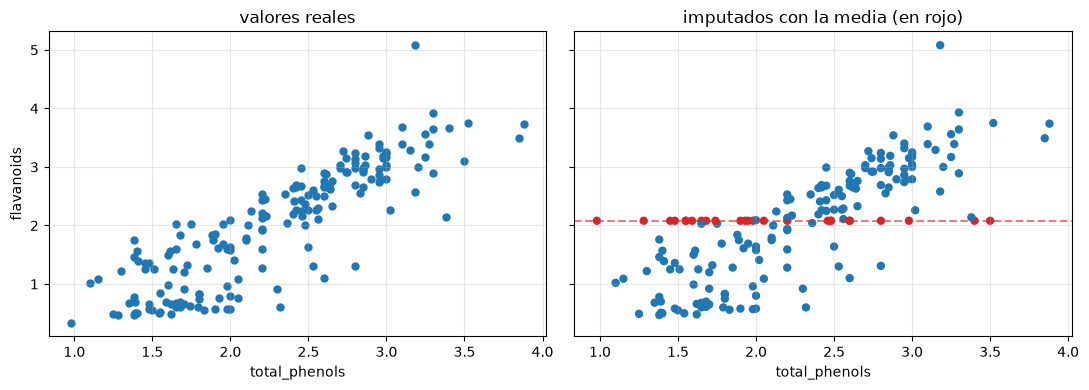

In [40]:
par = ["flavanoids", "total_phenols"]
print(f"correlación real                : {vinos_ori[par].corr().iloc[0, 1]:.3f}")
print(f"correlación con imputación media: {vinos_media[par].corr().iloc[0, 1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
axes[0].scatter(vinos_ori.total_phenols, vinos_ori.flavanoids, s=25)
axes[0].set_title("valores reales")
axes[1].scatter(vinos_media.total_phenols, vinos_media.flavanoids, s=25,
                c=np.where(MASCARA.flavanoids, "tab:red", "tab:blue"))
axes[1].axhline(medias.flavanoids, ls="--", color="tab:red", alpha=.6)
axes[1].set_title("imputados con la media (en rojo)")
for ax in axes:
    ax.set_xlabel("total_phenols")
axes[0].set_ylabel("flavanoids")
plt.tight_layout()
plt.show()

### 8.2 La moda, para las categóricas

In [41]:
moda = vinos["clase"].mode()[0]
print("moda de clase:", moda)
print("\ndistribución con faltantes:")
print(vinos["clase"].value_counts(dropna=False).to_string())

vinos_media["clase"] = vinos_media["clase"].fillna(moda)

comparacion_clase = pd.DataFrame({
    "real": vinos_ori["clase"].value_counts(),
    "imputada con la moda": vinos_media["clase"].value_counts(),
})
comparacion_clase["error"] = (comparacion_clase["imputada con la moda"]
                              - comparacion_clase["real"])
comparacion_clase

moda de clase: grignolino

distribución con faltantes:
clase
grignolino    68
barolo        57
barbera       43
NaN           10


,real,imputada con la moda,error
clase,,,
grignolino,71,78,7
barolo,59,57,-2
barbera,48,43,-5


In [42]:
# ¿Cuántas veces acertó la moda?
falta_clase = vinos["clase"].isna()
aciertos = (vinos_ori.loc[falta_clase, "clase"] == moda).sum()
print(f"faltantes en clase: {int(falta_clase.sum())}")
print(f"aciertos de la moda: {aciertos} ({100 * aciertos / falta_clase.sum():.0f} %)")

faltantes en clase: 10
aciertos de la moda: 3 (30 %)


Imputar con la moda equivale a apostar siempre a la categoría más frecuente, así que la tasa
de acierto ronda la proporción de esa categoría en el dataset. Y a cambio **desbalancea** la
distribución: la mayoritaria queda sobrerrepresentada y las otras pierden casos. Si esa
variable después es la clase a predecir, el desbalanceo se traslada al modelo.

## 9. Imputación con modelos implícitos

En lugar de inventar un valor con una fórmula, se lo **toma prestado de otra observación
parecida** (el *donante*). No hay un modelo explícito escrito: el modelo está implícito en
la definición de "parecido".

- 🧊 **Cold deck**: el donante viene de una fuente **externa** al dataset — una medición
  anterior, una tabla de referencia, otro relevamiento. En una serie de tiempo, rellenar con
  el valor del día anterior es cold deck.
- 🔥 **Hot deck**: el donante sale del **mismo** dataset. La implementación habitual es por
  vecinos más cercanos (`KNNImputer`), aunque también se usa elegir un donante al azar dentro
  de un estrato.

### 9.1 Cold deck

In [43]:
# Cold deck en su forma más común: la medición anterior de la misma unidad.
# Lo mostramos sobre los sensores, donde el orden temporal le da sentido.
serie = sensor.temp.copy()
serie.iloc[[20, 21, 40, 60]] = np.nan   # metemos unos nulos

cold = pd.DataFrame({
    "con faltantes": serie,
    "ffill (valor anterior)": serie.ffill(),
    "interpolación lineal": serie.interpolate(),
    "real": sensor.temp,
})
cold.iloc[18:24]

,con faltantes,ffill (valor anterior),interpolación lineal,real
18,17.916,17.916,17.916,17.916
19,17.004,17.004,17.004,17.004
20,NaN,17.004,17.585,18.035
21,NaN,17.004,18.166,19.294
22,18.747,18.747,18.747,18.747
23,19.088,19.088,19.088,19.088


### 9.2 Hot deck por vecinos más cercanos: `KNNImputer`

`KNNImputer` promedia los `k` vecinos más cercanos, midiendo la distancia sólo sobre las
variables presentes en cada par (`nan_euclidean`).

In [44]:
from sklearn.impute import KNNImputer

# Las dos versiones se diferencian SÓLO en si los datos van estandarizados: la cantidad
# de vecinos y el criterio de ponderación son idénticos, así la comparación es limpia.
PARAMS = dict(n_neighbors=5, weights="distance")

# a) sobre las variables crudas. La distancia euclídea suma las diferencias de las 13
#    variables, y `proline` (278 a 1680) le pasa por encima a `hue` (0,5 a 1,7): el vecino
#    "más cercano" termina decidiéndose casi sólo por el proline.
sin_escalar = pd.DataFrame(KNNImputer(**PARAMS).fit_transform(vinos[NUM]),
                           columns=NUM, index=vinos.index)

# b) estandarizando primero, para que las 13 variables pesen lo mismo en la distancia.
#    Después hay que volver a las unidades originales con inverse_transform.
escala = StandardScaler().fit(vinos[NUM])
con_escalar = pd.DataFrame(
    escala.inverse_transform(KNNImputer(**PARAMS).fit_transform(escala.transform(vinos[NUM]))),
    columns=NUM, index=vinos.index,
)

# La versión estandarizada es la que usamos en el resto de la guía
vinos_knn = vinos.copy()
vinos_knn[NUM] = con_escalar

m = MASCARA.flavanoids
comparacion_knn = pd.DataFrame({
    "valor real": vinos_ori.loc[m, "flavanoids"],
    "KNN sin escalar": sin_escalar.loc[m, "flavanoids"],
    "KNN escalado": con_escalar.loc[m, "flavanoids"],
    "media": vinos_media.loc[m, "flavanoids"],
})
comparacion_knn.head(10).round(3)

,valor real,KNN sin escalar,KNN escalado,media
0,3.06,3.027,3.109,2.081
7,2.51,2.510,2.796,2.081
23,2.37,2.343,2.761,2.081
58,3.67,2.870,3.288,2.081
63,3.10,2.411,2.783,2.081
66,3.18,3.213,3.156,2.081
76,2.03,2.060,2.263,2.081
78,1.85,2.144,2.058,2.081
83,1.59,2.300,0.853,2.081
84,2.21,2.319,2.749,2.081


In [45]:
# Error absoluto medio de cada versión sobre las celdas que borramos
error_abs = (comparacion_knn.drop(columns="valor real")
             .sub(comparacion_knn["valor real"], axis=0).abs().mean())
error_abs.round(3)

KNN sin escalar    0.498
KNN escalado       0.253
media              0.861
dtype: float64

Las dos versiones de KNN parten de la misma idea y dan resultados bien distintos. Sin
escalar, los vecinos se eligieron básicamente por parecido en `proline`, que no tiene por qué
tener nada que ver con los flavonoides; el error absoluto medio queda en casi el doble.

## 10. Imputación por regresión

Si una variable está correlacionada con otras, se puede **modelar** en función de ellas:
ajustar la regresión con las filas completas y usarla para predecir los faltantes.

In [46]:
# Buscamos el mejor predictor de flavanoids entre las demás variables
correlaciones = (vinos_ori[NUM].corr()["flavanoids"]
                 .drop("flavanoids").sort_values(key=abs, ascending=False))
correlaciones.head(5)

total_phenols                   0.865
od280/od315_of_diluted_wines    0.787
proanthocyanins                 0.653
hue                             0.543
nonflavanoid_phenols           -0.538
Name: flavanoids, dtype: float64

In [47]:
from sklearn.linear_model import LinearRegression

indep = ["total_phenols", "od280/od315_of_diluted_wines"]
dep = "flavanoids"

completas = vinos.dropna(subset=indep + [dep])
modelo = LinearRegression().fit(completas[indep], completas[dep])

print(f"filas usadas para ajustar: {len(completas)}")
print(f"R²   : {modelo.score(completas[indep], completas[dep]):.3f}")
print(f"coef : {dict(zip(indep, modelo.coef_.round(3)))}")
print(f"const: {modelo.intercept_:.3f}")

filas usadas para ajustar: 153
R²   : 0.795
coef : {'total_phenols': np.float64(0.972), 'od280/od315_of_diluted_wines': np.float64(0.505)}
const: -1.510


In [48]:
vinos_reg = vinos.copy()

# Las independientes también pueden tener faltantes: las completamos con la mediana
# para poder predecir
X_pred = vinos[indep].fillna(vinos[indep].median())
prediccion = modelo.predict(X_pred)

falta = vinos[dep].isna()
vinos_reg.loc[falta, dep] = prediccion[falta.to_numpy()]

# Para las otras dos usamos la media
vinos_reg[NUM] = vinos_reg[NUM].fillna(medias)

vinos_reg.loc[falta, [dep] + indep].head()

,flavanoids,total_phenols,od280/od315_of_diluted_wines
0,3.191,2.80,3.92
7,2.825,2.60,3.58
23,2.733,2.48,3.63
58,3.244,3.40,2.87
63,3.342,3.50,2.87


### 10.1 La versión multivariada: `IterativeImputer` (MICE)

Hacer una regresión a mano por variable no escala, y además desperdicia información: para
predecir `flavanoids` tuvimos que rellenar sus predictores con la mediana.

`IterativeImputer` automatiza la idea: modela **cada** variable incompleta en función de
todas las demás e **itera**.

In [49]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

mice = IterativeImputer(max_iter=20, random_state=SEMILLA)
vinos_mice = vinos.copy()
vinos_mice[NUM] = mice.fit_transform(vinos[NUM])

print(f"iteraciones hasta converger: {mice.n_iter_}")
vinos_mice.loc[m, FALTAN].head()

iteraciones hasta converger: 4


,flavanoids,magnesium,proline
0,3.351,127.0,1065.0
7,2.874,121.0,1295.0
23,2.817,95.0,1015.0
58,3.340,108.0,1285.0
63,3.046,87.0,420.0


### 10.2 Comparación de los métodos

Con el dataset original a mano podemos graficar el valor imputado contra el que realmente
había. La diagonal sería el acierto perfecto.

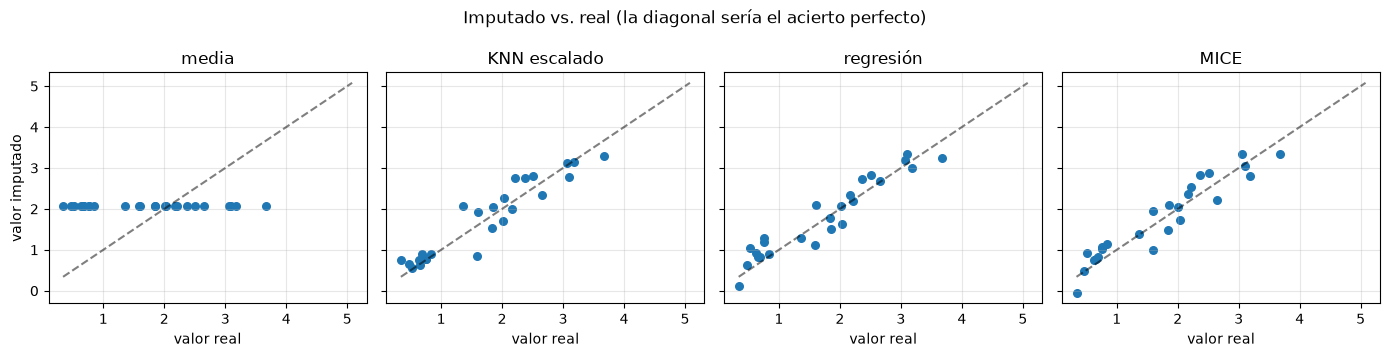

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True, sharey=True)
for (nombre, datos), ax in zip(
        [("media", vinos_media), ("KNN escalado", vinos_knn),
         ("regresión", vinos_reg), ("MICE", vinos_mice)], axes):
    ax.scatter(vinos_ori.loc[m, "flavanoids"], datos.loc[m, "flavanoids"], s=30)
    lims = [vinos_ori.flavanoids.min(), vinos_ori.flavanoids.max()]
    ax.plot(lims, lims, ls="--", color="black", alpha=.5)
    ax.set_title(nombre); ax.set_xlabel("valor real")
axes[0].set_ylabel("valor imputado")
fig.suptitle("Imputado vs. real (la diagonal sería el acierto perfecto)")
plt.tight_layout()
plt.show()

In [51]:
pd.DataFrame({
    "corr(flavanoids, total_phenols)": {
        "real": vinos_ori[par].corr().iloc[0, 1],
        "media": vinos_media[par].corr().iloc[0, 1],
        "KNN escalado": vinos_knn[par].corr().iloc[0, 1],
        "regresión": vinos_reg[par].corr().iloc[0, 1],
        "MICE": vinos_mice[par].corr().iloc[0, 1],
    }
}).round(3)

,"corr(flavanoids, total_phenols)"
real,0.865
media,0.783
KNN escalado,0.852
regresión,0.869
MICE,0.865


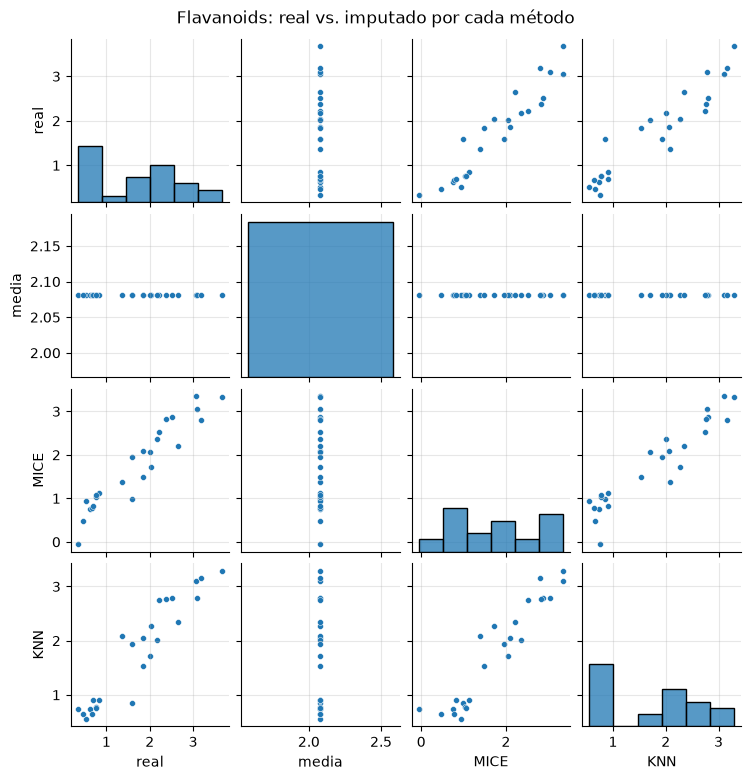

In [52]:
sns.pairplot(
    pd.DataFrame({
        "real": vinos_ori.loc[m, "flavanoids"].to_numpy(),
        "media": vinos_media.loc[m, "flavanoids"].to_numpy(),
        "MICE": vinos_mice.loc[m, "flavanoids"].to_numpy(),
        "KNN": vinos_knn.loc[m, "flavanoids"].to_numpy(),
    }), height=1.9, plot_kws={"s": 18},
)
plt.suptitle("Flavanoids: real vs. imputado por cada método", y=1.02)
plt.show()

La media es la única que no tiene ninguna relación con el valor real: su columna es una línea
horizontal. Las otras tres siguen la diagonal con distinto grado de dispersión.

## 11. Reducción de dimensionalidad: PCA

El Análisis de Componentes Principales busca nuevos ejes (**componentes**) que son
combinaciones lineales de las variables originales, ordenados por cuánta varianza explican
y **no correlacionados entre sí**.

Usamos el dataset completo (`vinos_ori`).

### 11.1 Por qué hay que estandarizar: la matriz de covarianzas

La covarianza depende de las unidades. Si una variable está medida en una escala mucho más
grande que las otras, su varianza domina y la primera componente termina siendo,
básicamente, esa variable.

In [53]:
varianzas = pd.DataFrame({
    "varianza": vinos_ori[NUM].var(),
    "desvío": vinos_ori[NUM].std(),
}).sort_values("varianza", ascending=False)
varianzas.round(2)

,varianza,desvío
proline,99166.72,314.91
magnesium,203.99,14.28
alcalinity_of_ash,11.15,3.34
color_intensity,5.37,2.32
malic_acid,1.25,1.12
flavanoids,1.00,1.00
alcohol,0.66,0.81
od280/od315_of_diluted_wines,0.50,0.71
total_phenols,0.39,0.63
proanthocyanins,0.33,0.57


In [54]:
from sklearn.decomposition import PCA

pca_crudo = PCA().fit(vinos_ori[NUM])
print("varianza explicada por CP1 sin estandarizar:",
      f"{pca_crudo.explained_variance_ratio_[0]:.4f}")
print("peso de cada variable en CP1 (las 3 mayores):")
print(pd.Series(np.abs(pca_crudo.components_[0]), index=NUM)
      .sort_values(ascending=False).head(3).round(4).to_string())

varianza explicada por CP1 sin estandarizar: 0.9981
peso de cada variable en CP1 (las 3 mayores):
proline              1.000
magnesium            0.018
alcalinity_of_ash    0.005


El 99,8 % de la "varianza explicada" es un artificio: `proline` tiene una varianza de
99.000 y `hue` de 0,05. La primera componente no descubrió nada, sólo copió la variable de
escala más grande. Con variables en unidades distintas, PCA **se hace sobre la matriz de
correlaciones**, que es lo mismo que estandarizar primero.

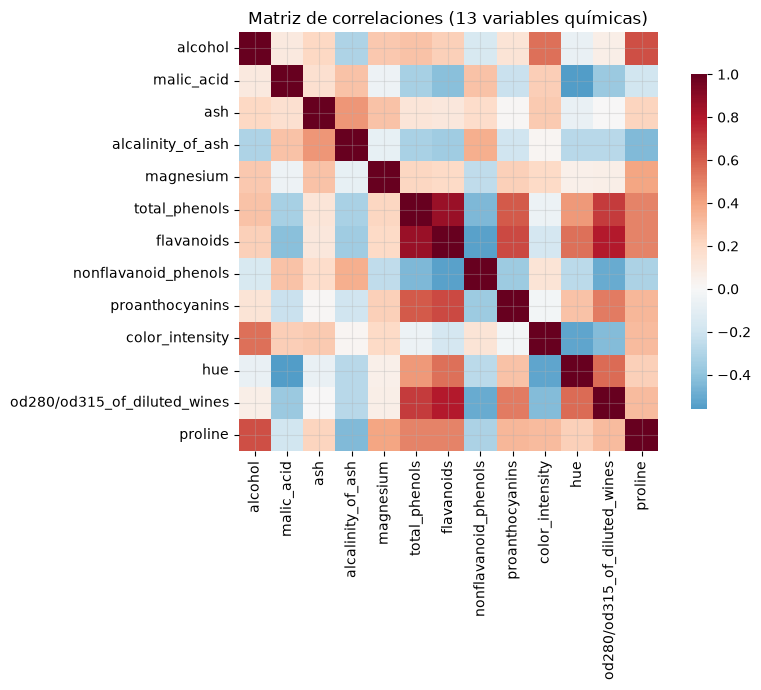

total_phenols  flavanoids                      0.865
flavanoids     od280/od315_of_diluted_wines    0.787
total_phenols  od280/od315_of_diluted_wines    0.700
flavanoids     proanthocyanins                 0.653
alcohol        proline                         0.644
total_phenols  proanthocyanins                 0.612
dtype: float64

In [55]:
correl = vinos_ori[NUM].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correl, cmap="RdBu_r", center=0, annot=False, square=True,
            cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Matriz de correlaciones (13 variables químicas)")
plt.tight_layout()
plt.show()

# Los pares más correlacionados: ahí está la redundancia que PCA va a comprimir
pares = correl.where(np.triu(np.ones(correl.shape), k=1).astype(bool)).stack()
pares.sort_values(key=abs, ascending=False).head(6).round(3)

### 11.2 PCA sobre las variables estandarizadas

In [56]:
X = StandardScaler().fit_transform(vinos_ori[NUM])
print("media ≈ 0:", X.mean().round(6), "| desvío ≈ 1:", X.std().round(6))

pca = PCA()          # sin n_components: calcula las 13
puntajes = pca.fit_transform(X)

CP = [f"CP{i+1}" for i in range(pca.n_components_)]
scores = pd.DataFrame(puntajes, columns=CP, index=vinos_ori.index)
scores.head()

media ≈ 0: 0.0 | desvío ≈ 1: 1.0


,CP1,CP2,CP3,CP4,CP5,CP6,CP7,CP8,CP9,CP10,CP11,CP12,CP13
0,3.317,1.443,-0.166,-0.216,0.693,0.224,0.596,-0.065,-0.641,1.021,-0.452,5.408e-01,-0.066
1,2.209,-0.333,-2.026,-0.291,-0.258,0.927,0.054,-1.024,0.309,0.160,-0.143,3.882e-01,0.004
2,2.517,1.031,0.983,0.725,-0.251,-0.549,0.424,0.344,1.178,0.113,-0.287,5.836e-04,0.022
3,3.757,2.756,-0.176,0.568,-0.312,-0.114,-0.383,-0.644,-0.053,0.239,0.760,-2.420e-01,-0.369
4,1.009,0.870,2.027,-0.410,0.298,0.407,0.444,-0.417,-0.327,-0.078,-0.526,-2.167e-01,-0.079


In [57]:
resumen_pca = pd.DataFrame({
    "% varianza": 100 * pca.explained_variance_ratio_,
    "% acumulado": 100 * pca.explained_variance_ratio_.cumsum(),
}, index=CP)
resumen_pca.round(2)

,% varianza,% acumulado
CP1,36.20,36.20
CP2,19.21,55.41
CP3,11.12,66.53
CP4,7.07,73.60
CP5,6.56,80.16
CP6,4.94,85.10
CP7,4.24,89.34
CP8,2.68,92.02
CP9,2.22,94.24
CP10,1.93,96.17


In [58]:
# Verificación de la ortogonalidad: la matriz de correlación de los puntajes es la identidad
scores[CP[:4]].corr().round(6)

,CP1,CP2,CP3,CP4
CP1,1.0,-0.0,0.0,0.0
CP2,-0.0,1.0,-0.0,0.0
CP3,0.0,-0.0,1.0,-0.0
CP4,0.0,0.0,-0.0,1.0


Las componentes son **ortogonales**: sus varianzas se suman sin solaparse, y por eso el
acumulado se puede leer directamente. Ésa es la propiedad que hace útil a PCA, cada
componente aporta información que ninguna otra tiene.

### 11.3 La matriz de *loadings*

Los **loadings** miden la relación entre cada variable original y cada componente. Con
variables estandarizadas se leen directamente como una **correlación**: van de −1 a 1, y su
cuadrado es la proporción de varianza de la variable que esa componente captura.

Se calculan a partir de `pca.components_` (los autovectores, que traen los pesos de la
combinación lineal) reescalados por el desvío de cada componente.

In [59]:
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                        index=NUM, columns=CP)
loadings[CP[:4]].round(3)

,CP1,CP2,CP3,CP4
alcohol,0.314,0.766,-0.250,-0.017
malic_acid,-0.533,0.356,0.107,0.516
ash,-0.004,0.501,0.755,-0.206
alcalinity_of_ash,-0.521,-0.017,0.738,0.059
magnesium,0.309,0.475,0.158,-0.338
total_phenols,0.859,0.103,0.176,0.190
flavanoids,0.920,-0.005,0.182,0.146
nonflavanoid_phenols,-0.649,0.046,0.205,-0.195
proanthocyanins,0.682,0.062,0.180,0.384
color_intensity,-0.193,0.840,-0.166,0.063


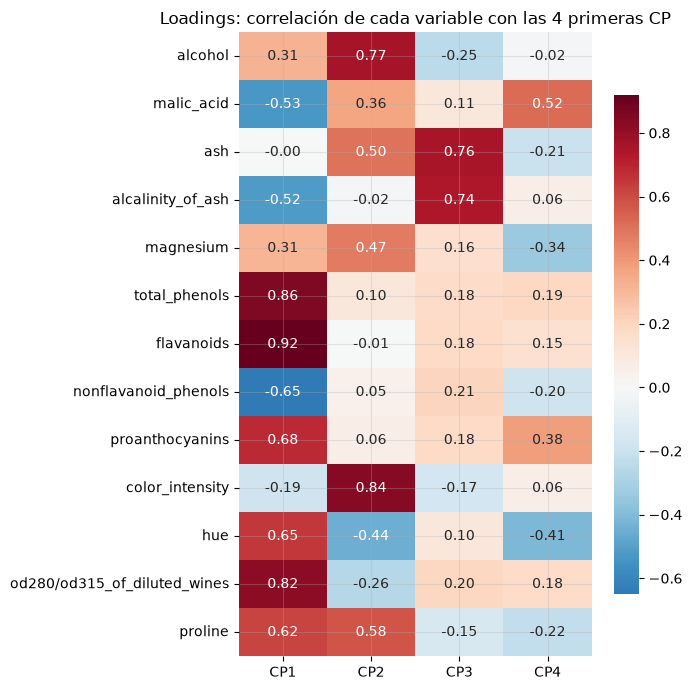

In [60]:
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(loadings[CP[:4]], cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Loadings: correlación de cada variable con las 4 primeras CP")
plt.tight_layout()
plt.show()

Cómo se lee esta matriz: **por columna** se ve de qué está hecha cada componente (los
loadings grandes en valor absoluto son las variables que la definen, y el signo indica en qué
sentido), **por fila** se ve qué tan bien representada está cada variable en el subespacio
elegido. Una variable con loadings chicos en todas las componentes retenidas es una variable
que se pierde al reducir.

### 11.4 Los vinos en el plano de las dos primeras componentes

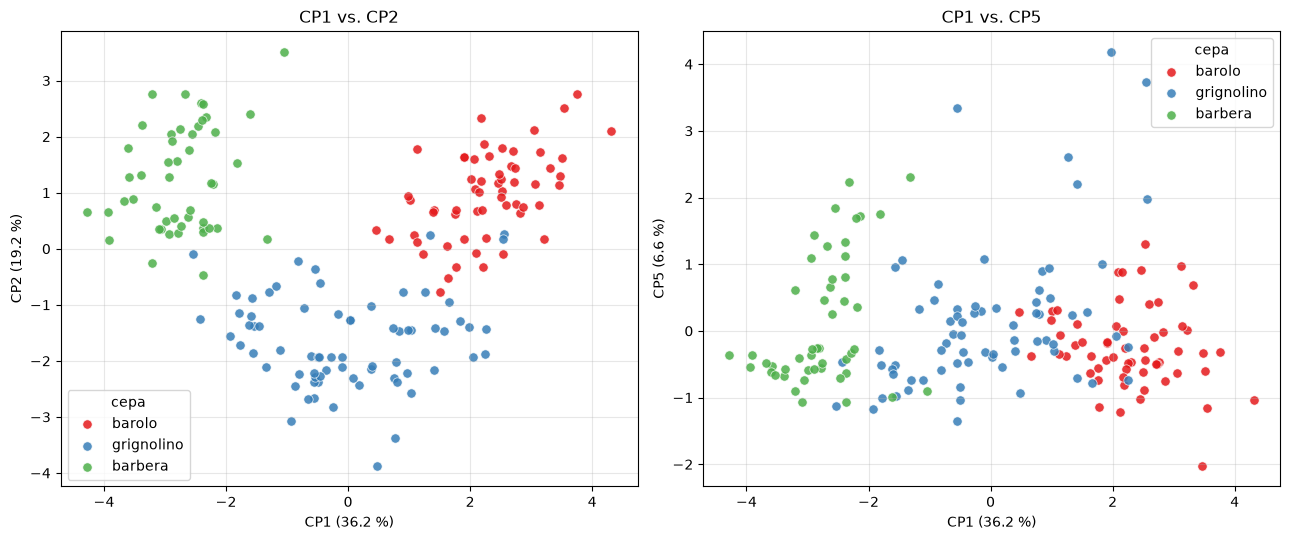

In [61]:
scores["clase"] = vinos_ori["clase"].to_numpy()
colores = {"barolo": "#e41a1c", "grignolino": "#377eb8", "barbera": "#4daf4a"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for (x, y), ax in zip([("CP1", "CP2"), ("CP1", "CP5")], axes):
    for cepa, color in colores.items():
        sub = scores[scores.clase == cepa]
        ax.scatter(sub[x], sub[y], c=color, s=45, label=cepa, alpha=.85,
                   edgecolor="white", linewidth=.5)
    vx = 100 * pca.explained_variance_ratio_[CP.index(x)]
    vy = 100 * pca.explained_variance_ratio_[CP.index(y)]
    ax.set_xlabel(f"{x} ({vx:.1f} %)"); ax.set_ylabel(f"{y} ({vy:.1f} %)")
    ax.set_title(f"{x} vs. {y}"); ax.legend(title="cepa")
plt.tight_layout()
plt.show()

### 11.5 Biplot

El biplot superpone las dos cosas: las **observaciones** proyectadas (puntos) y las
**variables** como vectores. Se lee así:

- Vectores **largos** → la variable está bien representada en este plano.
- Vectores en la **misma dirección** → variables correlacionadas positivamente entre sí.
- Vectores **opuestos** → correlación negativa. A **90°** → sin correlación.
- Un punto está en la dirección de un vector → esa observación tiene valores altos en esa
  variable.

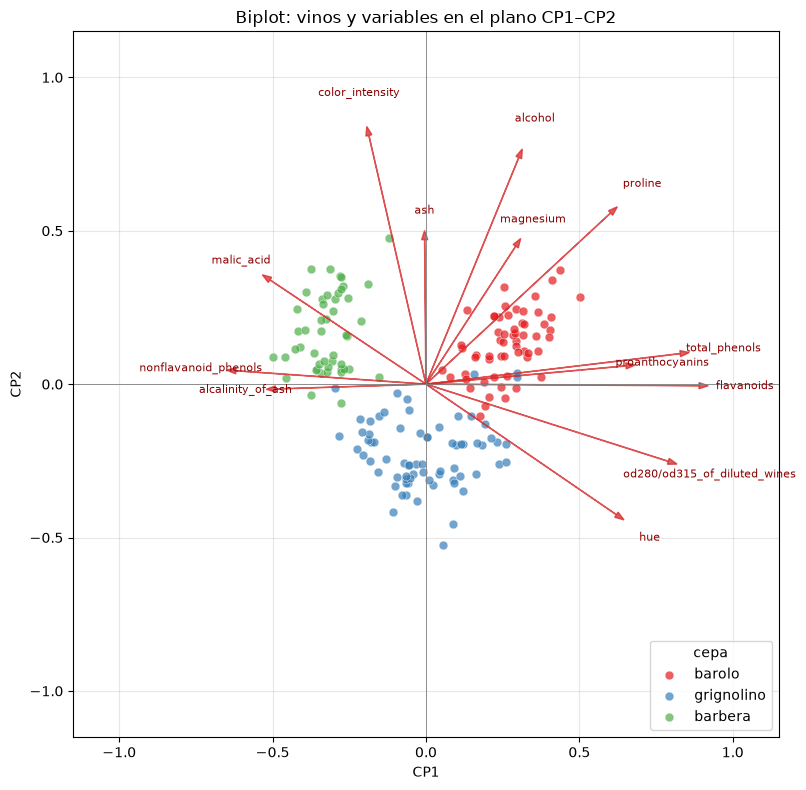

In [62]:
def biplot(scores, loadings, grupos=None, colores=None, ejes=("CP1", "CP2"), ax=None):
    """Biplot con los puntajes escalados a [-1, 1] y los loadings como vectores."""
    ex, ey = ejes
    if ax is None:
        _, ax = plt.subplots(figsize=(8.5, 8))

    # Escalamos los puntajes para que convivan con los loadings en el mismo eje
    xs = scores[ex] / (scores[ex].max() - scores[ex].min())
    ys = scores[ey] / (scores[ey].max() - scores[ey].min())

    if grupos is None:
        ax.scatter(xs, ys, s=35, alpha=.6)
    else:
        for g, color in colores.items():
            sel = grupos == g
            ax.scatter(xs[sel], ys[sel], c=color, s=40, alpha=.7, label=g,
                       edgecolor="white", linewidth=.4)
        ax.legend(title="cepa", loc="lower right")

    for var in loadings.index:
        dx, dy = loadings.loc[var, ex], loadings.loc[var, ey]
        ax.arrow(0, 0, dx, dy, color="tab:red", alpha=.75,
                 head_width=.02, length_includes_head=True)
        ax.text(dx * 1.13, dy * 1.13, var, color="darkred", ha="center",
                va="center", fontsize=8)

    ax.axhline(0, color="gray", lw=.6); ax.axvline(0, color="gray", lw=.6)
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.set_xlabel(ex); ax.set_ylabel(ey)
    return ax


ax = biplot(scores, loadings, grupos=scores.clase, colores=colores)
ax.set_title("Biplot: vinos y variables en el plano CP1–CP2")
plt.tight_layout()
plt.show()

### 11.6 La librería `pca`, para comparar

El paquete `pca` (ya incluido en el entorno de la materia) resuelve el gráfico de varianza,
el scatter y el biplot en una línea cada uno, y agrega la detección de outliers
multivariados con la distancia de Hotelling T². Sirve para chequear que nuestros gráficos
dan lo mismo.

In [63]:
from pca import pca as PCAlib

modelo_pca = PCAlib(n_components=5, verbose=40)   # verbose alto = menos mensajes
Xdf = pd.DataFrame(StandardScaler().fit_transform(vinos_ori[NUM]),
                   columns=NUM, index=vinos_ori.index)
resultados = modelo_pca.fit_transform(X=Xdf, row_labels=vinos_ori["clase"].astype(str))

print("varianza explicada acumulada:",
      np.round(100 * resultados["explained_var"], 1))

varianza explicada acumulada: [36.2 55.4 66.5 73.6 80.2]


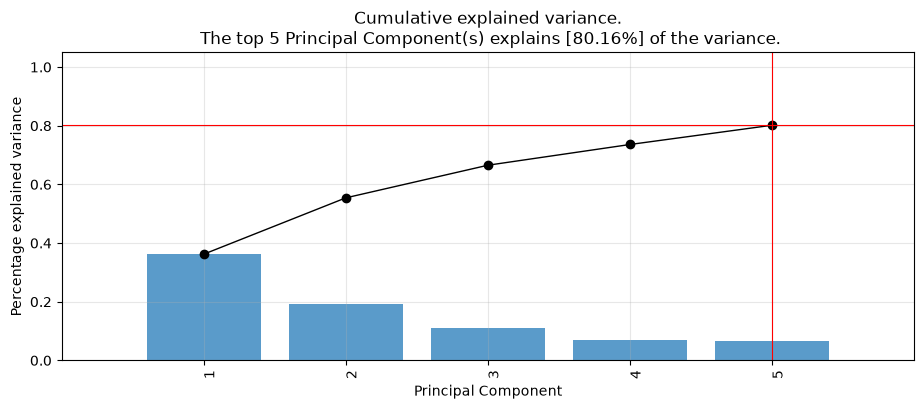

In [64]:
fig, ax = modelo_pca.plot(figsize=(11, 4))
plt.show()

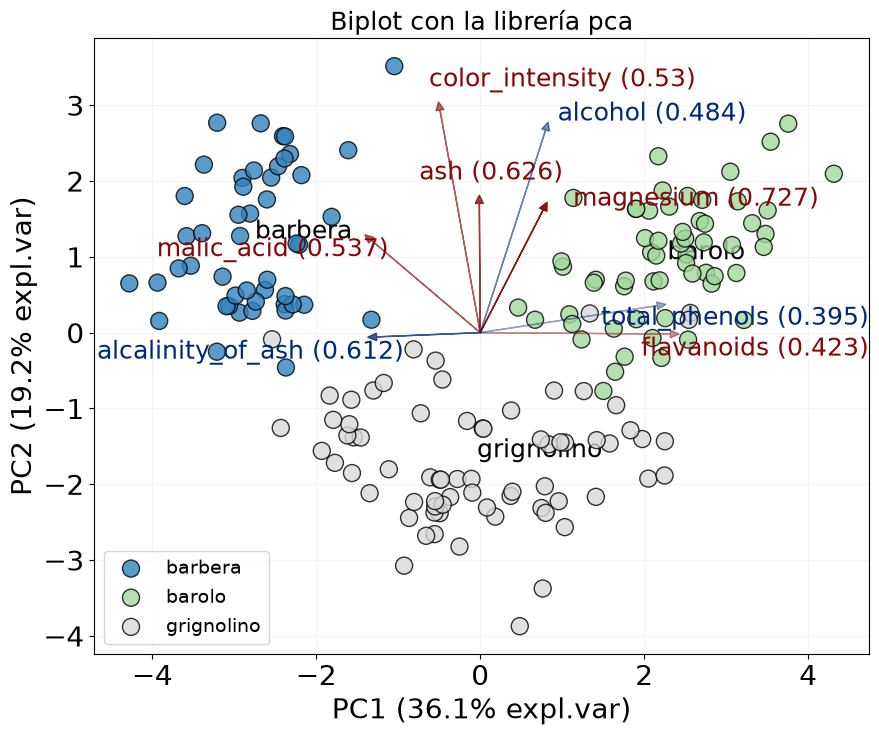

In [65]:
fig, ax = modelo_pca.biplot(n_feat=8, legend=True, figsize=(10, 8),
                            title="Biplot con la librería pca")
plt.show()

In [66]:
# Outliers multivariados: los vinos raros considerando todas las variables a la vez
salidas = modelo_pca.results["outliers"]
print(salidas.head())
print(f"\noutliers por Hotelling T² (p < 0.05): {int((salidas['y_bool']).sum())}")
print(f"outliers por SPE/DmodX               : {int((salidas['y_bool_spe']).sum())}")

        y_proba  p_raw  y_score  y_bool  y_bool_spe  y_score_spe
barolo    0.882  0.332   11.331   False       False        3.617
barolo    0.882  0.545    8.862   False       False        2.234
barolo    0.882  0.515    9.178   False       False        2.720
barolo    0.882  0.088   16.431   False       False        4.660
barolo    0.882  0.708    7.180   False       False        1.332

outliers por Hotelling T² (p < 0.05): 0
outliers por SPE/DmodX               : 0
